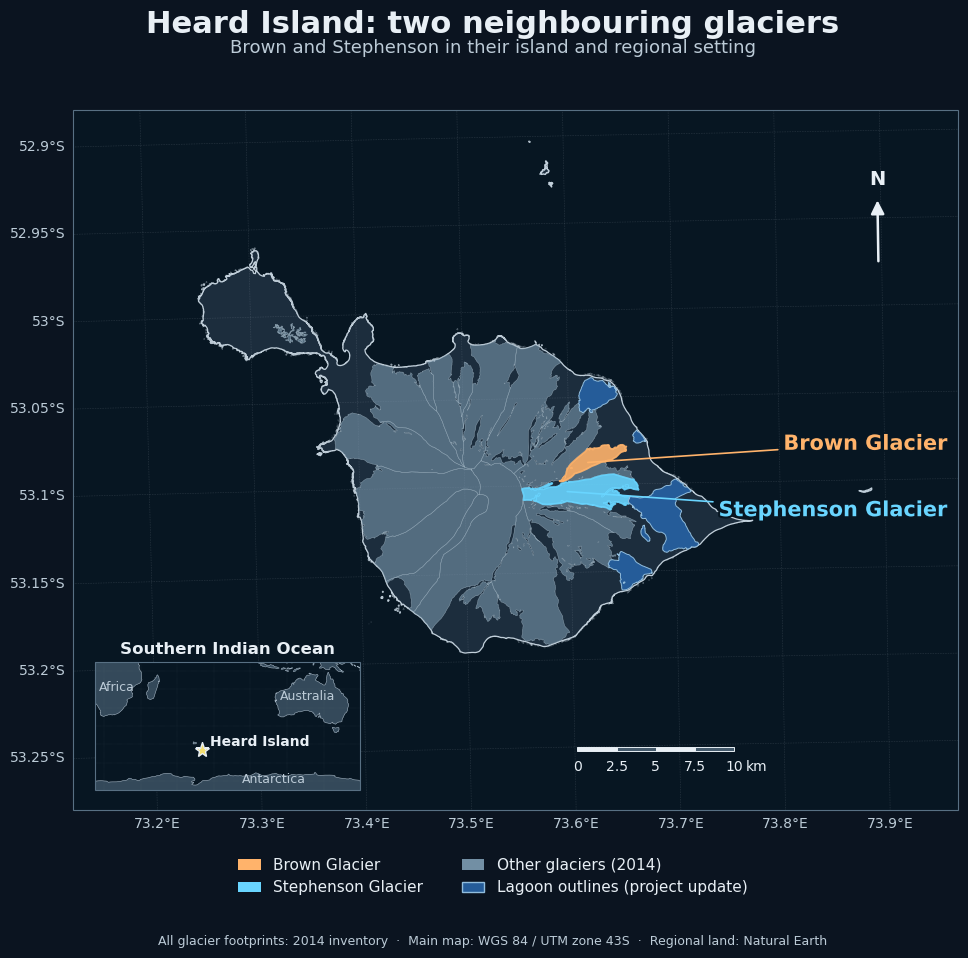

Saved locator to: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Figures\Book


In [3]:
## Locate Heard Island and the two focus glaciers ##

from pathlib import Path
import json
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.ticker import FixedLocator
from pyproj import Geod, Transformer
from shapely.geometry import box
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shutil import copy2

project_dir = next((p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "Input_Data").is_dir()
    and (p / "Output_Data" / "processed").is_dir()), None)
if project_dir is None:
    raise FileNotFoundError("Run this notebook from the project folder.")

input_dir = project_dir / "Input_Data"
processed_dir = project_dir / "Output_Data" / "processed"
book_figure_dir = project_dir / "Figures" / "Book"
book_figure_dir.mkdir(parents = True, exist_ok = True)

coast_path = input_dir / "HIMI_Features" / "himi_coastline_py.gpkg"
glacier_path = input_dir / "heard_island_shp" / "Glacier_2014.shp"
lagoon_path = input_dir / "heard_island_shp" / "UpdatedHI_Lagoons2014.shp"
style_path = processed_dir / "book_figure_style.json"
book_style = json.loads(style_path.read_text(encoding = "utf-8"))

# Select Heard Island from the supplied coastline polygons.
island_window = box(73.1, -53.35, 74.1, -52.85)
coast_ll = gpd.read_file(coast_path).to_crs(4326)
coast_ll = coast_ll.loc[
    coast_ll.geometry.notna() & ~coast_ll.geometry.is_empty].copy()
coast_ll.geometry = coast_ll.geometry.make_valid()
coast_ll = gpd.clip(coast_ll, island_window)
if coast_ll.empty:
    raise ValueError("No Heard Island coastline fell inside the study window.")

coast = coast_ll.to_crs(32743)
glaciers = gpd.read_file(glacier_path).to_crs(32743)
lagoons = gpd.read_file(lagoon_path).to_crs(32743)
glaciers.geometry = glaciers.geometry.make_valid()
lagoons.geometry = lagoons.geometry.make_valid()
glaciers = gpd.clip(glaciers, coast)
lagoons = gpd.clip(lagoons, coast)

focus_names = ["Brown", "Stephenson"]
focus = glaciers.loc[glaciers.name_1.isin(focus_names)].dissolve(
    by = "name_1", as_index = False)
if set(focus.name_1) != set(focus_names):
    raise ValueError("The 2014 inventory must contain Brown and Stephenson.")
context = glaciers.loc[~glaciers.name_1.isin(focus_names)]

colours = {
    "Brown": "#FFB36B", "Stephenson": "#69D5FF",
    "ocean": "#071622", "land": "#1C2D3D",
    "other_ice": "#728FA4", "lagoon": "#255C99",
    "text": "#E8EFF5", "muted": "#BCCBD7"}

# Main-map coordinates are metres in WGS 84 / UTM zone 43S.
map_crs = ccrs.UTM(zone = 43, southern_hemisphere = True)
geographic_crs = ccrs.PlateCarree()
left, bottom, right, top = coast.total_bounds
west, east = left - 8_000, right + 5_500
south, north = bottom - 10_000, top + 2_000
dx, dy = east - west, north - south

with plt.rc_context(book_style):
    fig = plt.figure(figsize = (15, 10))
    ax = fig.add_axes([0.065, 0.17, 0.90, 0.70], projection = map_crs)
    ax.set_facecolor(colours["ocean"])
    ax.set_extent([west, east, south, north], crs = map_crs)

    coast.plot(ax = ax, facecolor = colours["land"],
        edgecolor = "#C1CFDA", linewidth = 0.9, zorder = 2)
    if not context.empty:
        context.plot(ax = ax, facecolor = colours["other_ice"],
            edgecolor = "#AABECB", linewidth = 0.35, alpha = 0.65, zorder = 3)
    for name in focus_names:
        focus.loc[focus.name_1.eq(name)].plot(ax = ax,
            facecolor = colours[name], edgecolor = colours[name],
            linewidth = 1.2, alpha = 0.9, zorder = 4)
    if not lagoons.empty:
        lagoons.plot(ax = ax, facecolor = colours["lagoon"],
            edgecolor = "#91BDDD", linewidth = 0.7, zorder = 5)

    grid = ax.gridlines(crs = geographic_crs, draw_labels = True,
        linewidth = 0.45, color = "#AAB4BE", alpha = 0.3,
        linestyle = ":", x_inline = False, y_inline = False)
    grid.top_labels = False
    grid.right_labels = False
    grid.xlocator = FixedLocator(np.arange(73.1, 74.2, 0.1))
    grid.ylocator = FixedLocator(np.arange(-53.4, -52.8, 0.05))
    grid.xlabel_style = {"size": 10, "color": colours["muted"]}
    grid.ylabel_style = {"size": 10, "color": colours["muted"]}

    # Callouts identify only the two analytical focus glaciers.
    for name, offset in [("Brown", 1_200), ("Stephenson", -1_200)]:
        point = focus.loc[focus.name_1.eq(name)].geometry.iloc[0].representative_point()
        label = ax.annotate(f"{name} Glacier", xy = (point.x, point.y),
            xytext = (east - 700, point.y + offset),
            fontsize = 15, fontweight = "bold", color = colours[name],
            ha = "right", va = "center",
            arrowprops = {"arrowstyle": "-", "color": colours[name],
                "linewidth": 1.2}, zorder = 10)
        label.set_path_effects([path_effects.withStroke(
            linewidth = 3, foreground = colours["ocean"])])

    # Draw a segmented 10 km bar directly in the projected metre coordinates.
    scale_x, scale_y = west + 0.57 * dx, south + 0.085 * dy
    scale_height = dy * 0.0045
    for segment in range(4):
        ax.add_patch(mpatches.Rectangle(
            (scale_x + segment * 2_500, scale_y), 2_500, scale_height,
            facecolor = colours["text"] if segment % 2 == 0 else "#455B6D",
            edgecolor = colours["text"], linewidth = 0.7, zorder = 12))
    for distance in [0, 2.5, 5, 7.5, 10]:
        ax.text(scale_x + distance * 1_000, scale_y - dy * 0.013,
            f"{distance:g}", fontsize = 10, ha = "center", va = "top", zorder = 12)
    ax.text(scale_x + 10_700, scale_y - dy * 0.013,
        "km", fontsize = 10, ha = "left", va = "top", zorder = 12)

    # Orient the arrow towards true north at its plotted position.
    to_lonlat = Transformer.from_crs(32743, 4326, always_xy = True)
    to_utm = Transformer.from_crs(4326, 32743, always_xy = True)
    arrow_base = (west + dx * 0.91, south + dy * 0.78)
    lon, lat = to_lonlat.transform(*arrow_base)
    tip_lon, tip_lat, _ = Geod(ellps = "WGS84").fwd(lon, lat, 0, dy * 0.095)
    arrow_tip = to_utm.transform(tip_lon, tip_lat)
    ax.annotate("", xy = arrow_tip, xytext = arrow_base,
        arrowprops = {"arrowstyle": "-|>", "color": colours["text"],
            "linewidth": 1.8, "mutation_scale": 20}, zorder = 12)
    ax.text(arrow_tip[0], arrow_tip[1] + dy * 0.018, "N",
        fontsize = 14, fontweight = "bold", ha = "center", zorder = 12)

    # Keep the regional inset in the empty ocean southwest of the island.
    inset = ax.inset_axes([0.025, 0.025, 0.30, 0.19],
        projection = geographic_crs)
    inset.set_extent([15, 160, -75, -5], crs = geographic_crs)
    inset.set_facecolor(colours["ocean"])
    inset.add_feature(cfeature.LAND.with_scale("110m"),
        facecolor = "#34495A", edgecolor = "#A5B6C4", linewidth = 0.4)
    inset.gridlines(linewidth = 0.3, color = "#9AA4AE",
        alpha = 0.25, linestyle = ":")
    inset.plot(73.5, -53.1, marker = "*", markersize = 11,
        markerfacecolor = "#F4DF70", markeredgecolor = colours["text"],
        transform = geographic_crs, zorder = 5)
    inset.text(78, -51, "Heard Island", fontsize = 10, fontweight = "bold",
        transform = geographic_crs, zorder = 5)
    for text, lon, lat in [("Africa", 27, -21), ("Australia", 131, -26),
            ("Antarctica", 113, -71)]:
        inset.text(lon, lat, text, fontsize = 9, color = colours["muted"],
            ha = "center", transform = geographic_crs)
    inset.set_title("Southern Indian Ocean", fontsize = 12, pad = 6)

    legend_items = [mpatches.Patch(facecolor = colours[name], label = f"{name} Glacier")
        for name in focus_names]
    legend_items.extend([
        mpatches.Patch(facecolor = colours["other_ice"], label = "Other glaciers (2014)"),
        mpatches.Patch(facecolor = colours["lagoon"], edgecolor = "#91BDDD",
            label = "Lagoon outlines (project update)")])
    fig.legend(handles = legend_items, loc = "lower center",
        bbox_to_anchor = (0.5, 0.071), ncol = 2, fontsize = 11,
        columnspacing = 2.5, handlelength = 1.5)
    fig.suptitle("Heard Island: two neighbouring glaciers", y = 0.97,
        fontsize = 22, fontweight = "bold")
    fig.text(0.5, 0.927, "Brown and Stephenson in their island and regional setting",
        ha = "center", fontsize = 13, color = colours["muted"])
    fig.text(0.5, 0.035,
        "All glacier footprints: 2014 inventory  ·  Main map: WGS 84 / UTM zone 43S  ·  Regional land: Natural Earth",
        ha = "center", fontsize = 9, color = colours["muted"])

    for extension in ["png", "svg"]:
        fig.savefig(book_figure_dir / f"01_study_area_locator.{extension}",
            dpi = 300, bbox_inches = "tight", facecolor = fig.get_facecolor())
    plt.show()

print(f"Saved locator to: {book_figure_dir}")

In [2]:
## Stage the selected campaign photograph for the book ##

photo_candidates = [path for path in project_dir.rglob("calved.jpg")
    if "2003-04_CampaignData" in path.parts
    and any("scotty" in part.lower() for part in path.parts)]
if len(photo_candidates) != 1:
    raise FileNotFoundError(
        f"Expected one calved.jpg in Scotty's campaign folder; found {len(photo_candidates)}. "
        "Check the campaign folder's location inside the project.")

photo_source = photo_candidates[0]
photo_destination = book_figure_dir / "calved.jpg"
copy2(photo_source, photo_destination)
print(f"Book photograph: {photo_destination}\nOriginal: {photo_source}")

Book photograph: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Figures\Book\calved.jpg
Original: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Input_Data\2003-04_CampaignData\scotty digital pics\Calved.jpg
